In [1]:
import copy
import time
# from multiprocessing.managers import SharedMemoryManager
import click
import matplotlib.pyplot as plt
import numpy as np
import torch

import dill
import hydra
import tqdm
from omegaconf import OmegaConf
import scipy.spatial.transform as st
from diffusion_policy.common import debug
from diffusion_policy.common.pytorch_util import dict_apply
from diffusion_policy.workspace.base_workspace import BaseWorkspace
from diffusion_policy.policy.base_image_policy import BaseImagePolicy
import pickle
import os

path_ckpt = \
"/home/ali/shared_volume/avatar_behavior_cloning/training/diffusion_policy/data/outputs/2024.10.20/16.19.43_train_diffusion_unet_hybrid_avatar_overfit_bottle_lift/checkpoints/latest.ckpt"
ckpt_path = os.path.join(os.getcwd(), path_ckpt)
dataset_path = os.path.join(os.getcwd(), "data/_replay_buffer.zarr")



In [3]:
## Normalization Investigation


Load checkpoint + cfg
Load dataset
Construct


/home/ali/miniconda3/envs/test_310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


get all obs


100%|██████████| 56/56 [00:00<00:00, 700.16it/s]


get gt vs inferred act


100%|██████████| 14/14 [00:02<00:00,  5.63it/s]


24
saved saved_png_act_rdda_right_act.png
saved saved_png_act_right_arm_ee_pose.png
saved saved_png_act_rdda_left_act.png
saved saved_png_act_left_arm_ee_pose.png


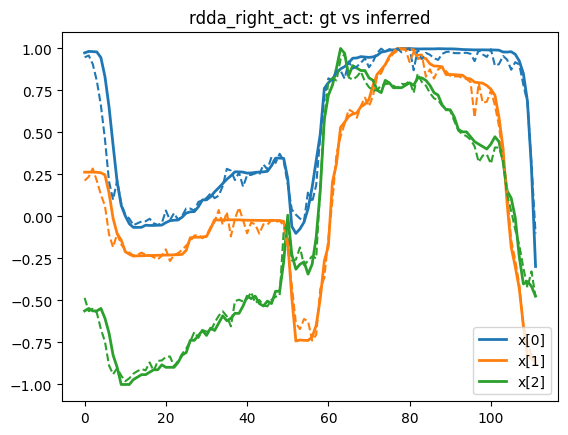

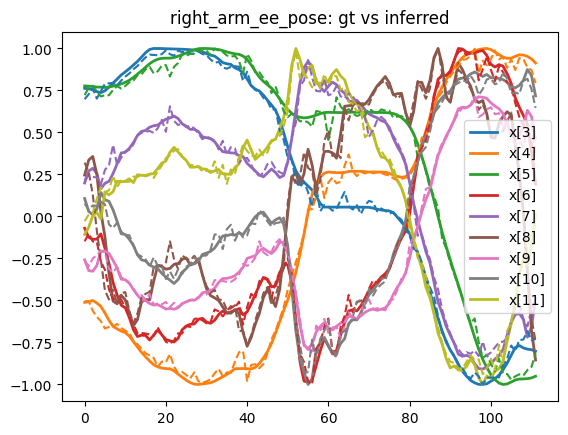

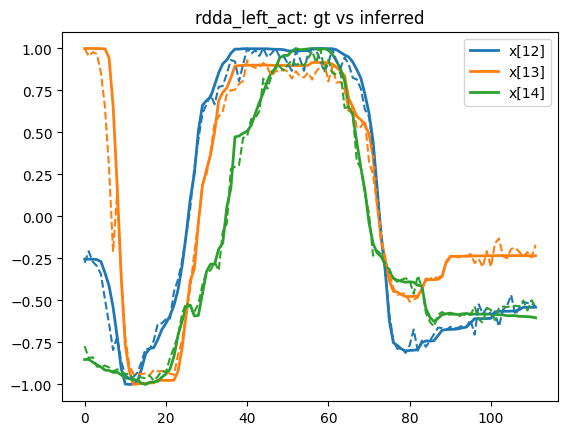

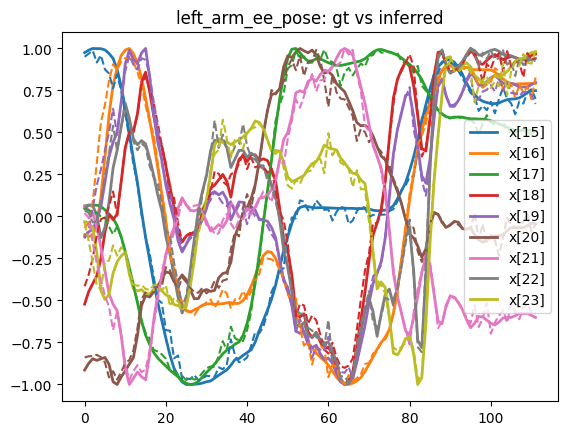

In [2]:

# @debug.iex
# def main():
print("Load checkpoint + cfg")
payload = torch.load(open(ckpt_path, 'rb'), pickle_module=dill)
cfg = payload['cfg']

cfg.policy.num_inference_steps = 8

print("Load dataset")
# cfg.task.dataset = dataset_path
dataset = hydra.utils.instantiate(cfg.task.dataset)

print("Construct")
cls = hydra.utils.get_class(cfg._target_)
workspace = cls(cfg)
workspace: BaseWorkspace
workspace.load_payload(payload, exclude_keys=None, include_keys=None)

# diffusion model
policy: BaseImagePolicy
policy = workspace.model
if cfg.training.use_ema:
    policy = workspace.ema_model

torch.set_grad_enabled(False)

normalizer = copy.deepcopy(policy.normalizer)

device = torch.device('cuda')
policy.eval().to(device)

# TODO: Plot normalized values.

count = len(dataset)//11
# dataset = dataset[:4]
print("get all obs")
obs_traj = {}
for i in tqdm.trange(1, count, policy.n_obs_steps):
    batch = dataset[i]
    obs_dict = batch["obs"]
    obs_dict = normalizer.normalize(obs_dict)
    for k, v in obs_dict.items():
        if k not in obs_traj:
            obs_traj[k] = []
        obs_traj[k].extend(list(v.numpy()))

# Convert to numpy arrays.
obs_traj = {k: np.array(v) for k, v in obs_traj.items()}
# for field, value in obs_traj.items():
#     _, D = value.shape
#     indices = np.arange(D)
#     label = [f"x[{x}]" for x in indices]

#     plt.figure()
#     plt.xlabel("obs index")
#     plt.title(f"{field}: used for inference")
#     plt.plot(value)

#     # plt.show()
#     file = f'saved_png_obs_{field}.png'
#     plt.savefig(file)
#     print(f"saved {file}")

act_start = policy.n_obs_steps - 1
act_end = act_start + policy.n_action_steps
act_slice = slice(act_start, act_end)

print("get gt vs inferred act")
gt_actions = []
inferred_actions = []

act_normalizer = normalizer['action']

for i in tqdm.trange(1, count, policy.n_action_steps):
    batch = dataset[i]
    obs_dict, gt_action = batch["obs"], batch["action"]
    obs_dict_torched = dict_apply(
        obs_dict, lambda x: x.cuda().unsqueeze(0)
    )
    result = policy.predict_action(obs_dict_torched)
    # Use full action, and downselect.
    action = result["action_pred"][0].cpu()

    action = act_normalizer.normalize(action)
    gt_action = act_normalizer.normalize(gt_action)

    action = action.numpy()
    gt_action = gt_action.numpy()
    assert len(action) == len(gt_action)

    action = action[act_slice]
    gt_action = gt_action[act_slice]

    for action_j, gt_action_j in zip(action, gt_action):
        inferred_actions.append(action_j)
        gt_actions.append(gt_action_j)

# Convert lists to NumPy arrays

inferred = np.array(inferred_actions)
ground_truth = np.array(gt_actions)
print(len(ground_truth[0]))
act_fields = {
    "rdda_right_act": slice(0, 3),
    "right_arm_ee_pose": slice(3, 12),
    "rdda_left_act": slice(12, 15),
    "left_arm_ee_pose": slice(15, 24),
}
all_indices = np.arange(24)

for field, indices in act_fields.items():
    label = [f"x[{x}]" for x in all_indices[indices]]

    plt.figure()
    plt.title(f"{field}: gt vs inferred")
    plt.plot([i[indices] for i in ground_truth], label=label, linewidth=2)
    plt.gca().set_prop_cycle(None)
    plt.plot([i[indices] for i in inferred], linestyle="--")
    plt.legend()

    # plt.show()
    file = f'saved_png_act_{field}.png'
    plt.savefig(file)
    print(f"saved {file}")

    # import pdb; pdb.set_trace()
# main()

In [12]:
print("get all obs")
obs_traj = {}
for i in tqdm.trange(1, count, policy.n_obs_steps):
    batch = dataset[i]
    obs_dict = batch["obs"]
    # obs_dict = normalizer.normalize(obs_dict)
    for k, v in obs_dict.items():
        if k not in obs_traj:
            obs_traj[k] = []
        obs_traj[k].extend(list(v.numpy()))

# Convert to numpy arrays.
obs_traj = {k: np.array(v) for k, v in obs_traj.items()}
#  one_complete_traj_left_rdda = []



get all obs


100%|██████████| 56/56 [00:00<00:00, 960.20it/s]


In [13]:
raw_signal = obs_traj["rdda_left_obs"][:112]

normalized_obs_dict = normalizer.normalize(obs_traj)

if len(raw_signal) != len(normalized_obs_dict["rdda_left_obs"]):
    print("Length mismatch")
    print(len(raw_signal), len(normalized_obs_dict["rdda_left_obs"]))

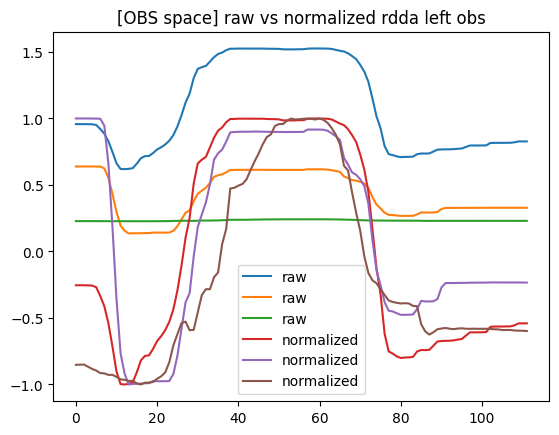

In [9]:
# Plot Raw and Normalized Observations

plt.figure()
plt.title("[OBS space] raw vs normalized rdda left obs")
plt.plot(raw_signal, label="raw")
plt.plot(normalized_obs_dict["rdda_left_obs"].cpu().numpy().squeeze(), label="normalized")
plt.legend()

get all actions


100%|██████████| 56/56 [00:00<00:00, 968.44it/s]

392
24


ValueError: label must be scalar or have the same length as the input data, but found 9 for 3 datasets.

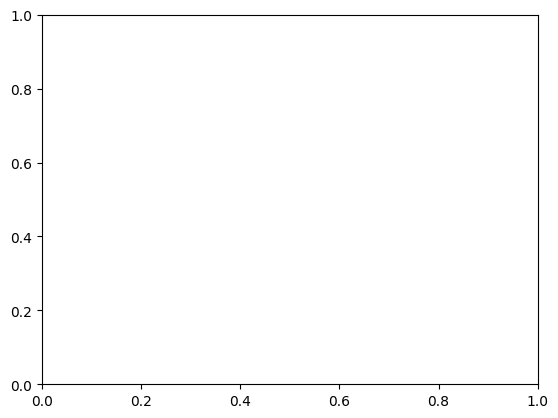

In [33]:
# Plot Raw and Normalized Actions

print("get all actions")
# action_traj = {}
unnormalized_actions = []
normalized_actions = []
act_normalizer = normalizer['action']
for i in tqdm.trange(1, count, policy.n_obs_steps):
    batch = dataset[i]
    un_action = batch["action"].numpy()
    normed_action = act_normalizer.normalize(un_action).numpy()
    un_action = un_action[act_slice]
    normed_action = normed_action[act_slice]
    # unnormalized_actions.append(batch["action"])
    # normalized_actions.append(act_normalizer.normalize(batch["action"]))
    # obs_dict = normalizer.normalize(obs_dict)
    # for k, v in action_dict:
    #     if k not in action_traj:
    #         action_traj[k] = []
    #     action_traj[k].extend(list(v.numpy()))
    for action_j, normalized_actions_j in zip(un_action[act_slice], normed_action[act_slice]):
        unnormalized_actions.append(action_j)
        normalized_actions.append(normalized_actions_j)

# plot both raw and normalized actions

# plt.figure()
# print()
# plt.title("raw vs normalized actions")
print(len(normalized_actions))
print(len(normalized_actions[0]))
# print(len(unnormalized_actions))
x_axis = np.arange(len(normalized_actions))
plt.figure()
plt.plot([i[slice(12, 15)] for i in np.array(normalized_actions)], label=label, linewidth=2)
# plt.gca().set_prop_cycle(None)
# plt.plot([i[12:15] for i in unnormalized_actions], linestyle="--")
plt.legend()
# print(len(actions[act_slice]), len(normalized_actions[act_slice]))
# plt.plot(unnormalized_actions, label="raw")
# plt.plot(unnormalized_actions, label="normalized")


In [31]:
normalized_actions

[tensor([ 1.2888,  0.3078, -0.0352,  0.0139, -0.0616, -0.0616,  0.9610,  0.2197,
         -0.1680, -0.2165,  0.9756,  0.0376,  0.9574,  0.6390,  0.2284,  0.0306,
         -0.0196, -0.0700,  0.9721, -0.1897, -0.1380,  0.1770,  0.9792, -0.0990]),
 tensor([ 1.2883,  0.3078, -0.0352,  0.0130, -0.0612, -0.0618,  0.9607,  0.2214,
         -0.1672, -0.2169,  0.9752,  0.0448,  0.9571,  0.6389,  0.2283,  0.0314,
         -0.0193, -0.0699,  0.9727, -0.1883, -0.1354,  0.1753,  0.9792, -0.1025]),
 tensor([ 1.2873,  0.3077, -0.0352,  0.0121, -0.0621, -0.0622,  0.9608,  0.2184,
         -0.1709, -0.2135,  0.9758,  0.0468,  0.9563,  0.6388,  0.2282,  0.0314,
         -0.0164, -0.0700,  0.9734, -0.1842, -0.1363,  0.1682,  0.9783, -0.1212]),
 tensor([ 1.2704,  0.3072, -0.0352,  0.0115, -0.0633, -0.0622,  0.9614,  0.2094,
         -0.1786, -0.2050,  0.9778,  0.0428,  0.9510,  0.6387,  0.2281,  0.0313,
         -0.0091, -0.0705,  0.9748, -0.1774, -0.1354,  0.1570,  0.9763, -0.1492]),
 tensor([ 1.2137,  0